## 11.7. The Transformer Architecture

In [1]:
import math
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

### 11.7.1. Model

![](https://d2l.ai/_images/transformer.svg)

### 11.7.2. Positionwise Feed-Forward Networks

In [2]:
class PositionWiseFFN(nn.Module):  #@save
    """The positionwise feed-forward network."""
    def __init__(self, ffn_num_hiddens, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.LazyLinear(ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [10]:
ffn = PositionWiseFFN(4, 8)
ffn.eval()
X_test = torch.ones((2, 3, 4))
X_test.shape, X_test

(torch.Size([2, 3, 4]),
 tensor([[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],
 
         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]]]))

In [12]:
trans_1 = ffn.relu(ffn.dense1(X_test))
trans_1.shape, trans_1

(torch.Size([2, 3, 4]),
 tensor([[[0.0000, 0.1627, 0.0000, 0.0000],
          [0.0000, 0.1627, 0.0000, 0.0000],
          [0.0000, 0.1627, 0.0000, 0.0000]],
 
         [[0.0000, 0.1627, 0.0000, 0.0000],
          [0.0000, 0.1627, 0.0000, 0.0000],
          [0.0000, 0.1627, 0.0000, 0.0000]]], grad_fn=<ReluBackward0>))

In [15]:
y_ffn = ffn(X_test)
y_ffn.shape, y_ffn[0].shape, y_ffn[0]

(torch.Size([2, 3, 8]),
 torch.Size([3, 8]),
 tensor([[ 0.2574, -0.3693, -0.0925, -0.5465, -0.1285, -0.3039, -0.3186,  0.2045],
         [ 0.2574, -0.3693, -0.0925, -0.5465, -0.1285, -0.3039, -0.3186,  0.2045],
         [ 0.2574, -0.3693, -0.0925, -0.5465, -0.1285, -0.3039, -0.3186,  0.2045]],
        grad_fn=<SelectBackward0>))

### 11.7.3. Residual Connection and Layer Normalization

In [16]:
ln = nn.LayerNorm(2)
bn = nn.LazyBatchNorm1d()
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# Compute mean and variance from X in the training mode
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [17]:
X.shape, X

(torch.Size([2, 2]),
 tensor([[1., 2.],
         [2., 3.]]))

In [37]:
m = torch.mean(X, dim=-1, keepdim=True)
v = torch.var(X, dim=-1, unbiased=False, keepdim=True)
m.shape, m, "", v.shape, v

(torch.Size([2, 1]),
 tensor([[1.5000],
         [2.5000]]),
 '',
 torch.Size([2, 1]),
 tensor([[0.2500],
         [0.2500]]))

In [38]:
(X - m) / torch.sqrt(v + eps)

tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]])

In [39]:
class AddNorm(nn.Module):  #@save
    """The residual connection followed by layer normalization."""
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [40]:
add_norm = AddNorm(4, 0.5)
shape = (2, 3, 4)
d2l.check_shape(add_norm(torch.ones(shape), torch.ones(shape)), shape)

### 11.7.4. Encoder

In [41]:
class TransformerEncoderBlock(nn.Module):  #@save
    """The Transformer encoder block."""
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias=False):
        super().__init__()
        self.attention = self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout, use_bias)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [42]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
encoder_blk.eval()
d2l.check_shape(encoder_blk(X, valid_lens), X.shape)

In [44]:
X.shape, valid_lens.shape, valid_lens

(torch.Size([2, 100, 24]), torch.Size([2]), tensor([3, 2]))

In [45]:
torch.repeat_interleave(valid_lens, repeats=8, dim=0)

tensor([3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2])

In [64]:
X_1 = X.reshape(X.shape[0], X.shape[1], 8, -1)
X_2 = X_1.permute(0, 2, 1, 3)
X_3 = X_2.reshape(-1, X_2.shape[2], X_2.shape[3])
X.shape, X_1.shape, X_2.shape, X_3.shape

(torch.Size([2, 100, 24]),
 torch.Size([2, 100, 8, 3]),
 torch.Size([2, 8, 100, 3]),
 torch.Size([16, 100, 3]))

In [92]:
d_test = X_3.shape[-1]
print(f"d_test: {d_test}\t|\t{X_3.transpose(1, 2).shape}\n")
bmm_1 = torch.bmm(X_3, X_3.transpose(1, 2)) / math.sqrt(d_test)
test_X_3 = torch.rand(16, 100, 3)
torch.all(test_X_3.transpose(1, 2) == test_X_3.permute(0, 2, 1))

d_test: 3	|	torch.Size([16, 3, 100])



tensor(True)

In [97]:
valid_lens2 = torch.repeat_interleave(valid_lens, repeats=8, dim=0)
valid_lens2.dim(), torch.repeat_interleave(valid_lens2, test_X_3.shape[1]).shape

(1, torch.Size([1600]))

In [99]:
class TransformerEncoder(d2l.Encoder):  #@save
    """The Transformer encoder."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, use_bias=False):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias))

    def forward(self, X, valid_lens):
        # Since positional encoding values are between -1 and 1, the embedding
        # values are multiplied by the square root of the embedding dimension
        # to rescale before they are summed up
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return X

In [101]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)
d2l.check_shape(encoder(torch.ones((2, 100), dtype=torch.long), valid_lens), (2, 100, 24))

### 11.7.5. Decoder

In [102]:
class TransformerDecoderBlock(nn.Module):
    # The i-th block in the Transformer decoder
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, i):
        super().__init__()
        self.i = i
        self.attention1 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.attention2 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # During training, all the tokens of any output sequence are processed
        # at the same time, so state[2][self.i] is None as initialized. When
        # decoding any output sequence token by token during prediction,
        # state[2][self.i] contains representations of the decoded output at
        # the i-th block up to the current time step
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), dim=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # Shape of dec_valid_lens: (batch_size, num_steps), where every
            # row is [1, 2, ..., num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None
        # Self-attention
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # Encoder-decoder attention. Shape of enc_outputs:
        # (batch_size, num_steps, num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [103]:
decoder_blk = TransformerDecoderBlock(24, 48, 8, 0.5, 0)
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
d2l.check_shape(decoder_blk(X, state)[0], X.shape)

In [118]:
state[0].shape, state[0], state[1], state[2][0].shape, state[2][0]

(torch.Size([2, 100, 24]),
 tensor([[[-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          ...,
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132]],
 
         [[-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          ...,
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132],
          [-2.2820,  0.4852,  0.9132,  ..., -0.9610,  0.3422,  0.4132]]],
        grad_fn=<NativeLayerNormBackward0>),
 tensor([3, 2]),
 torch.Size(

In [163]:
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_blks = num_blks
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerDecoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, i))
        self.dense = nn.LazyLinear(vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None] * self.num_blks]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # Decoder self-attention weights
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            # Encoder-decoder attention weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

### 11.7.6. Training

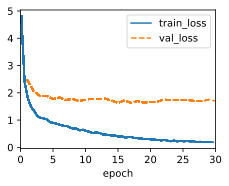

In [164]:
data = d2l.MTFraEng(batch_size=128)
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 64, 4
encoder = TransformerEncoder(len(data.src_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = TransformerDecoder(len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = d2l.Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],lr=0.001)
trainer = d2l.Trainer(max_epochs=30, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [165]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{d2l.bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['il', 'est', 'mouillé', '.'], bleu,0.658
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


In [168]:
preds

tensor([[201,   0,   4,   5,   5,   5,   5,   5,   5],
        [105, 148,   2,   4,   5,   5,   5,   5,   5],
        [102,  77, 131,   2,   4,   5,   5,   5,   5],
        [108, 183,  47, 129,   2,   4,   5,   5,   5]], device='cuda:0')

In [226]:
_, dec_attention_weights = model.predict_step(data.build([engs[-1]], [fras[-1]]), d2l.try_gpu(), data.num_steps, True)
enc_attention_weights1 = torch.cat(model.encoder.attention_weights, 0)
shape = (num_blks, num_heads, -1, data.num_steps)
enc_attention_weights = enc_attention_weights1.reshape(shape)
d2l.check_shape(enc_attention_weights,(num_blks, num_heads, data.num_steps, data.num_steps))

In [228]:
enc_attention_weights.shape, enc_attention_weights1.shape

(torch.Size([2, 4, 9, 9]), torch.Size([8, 9, 9]))

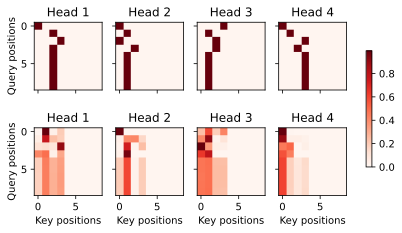

In [222]:
d2l.show_heatmaps(
    enc_attention_weights.cpu(), xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

In [179]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weights
                            for attn in step for blk in attn for head in blk]
len(dec_attention_weights_2d), set(len(x) for x in dec_attention_weights_2d)

(144, {1, 2, 3, 4, 5, 6, 7, 8, 9})

In [223]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weights
                            for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
shape = (-1, 2, num_blks, num_heads, data.num_steps)
dec_attention_weights = dec_attention_weights_filled.reshape(shape)
dec_self_attention_weights, dec_inter_attention_weights = dec_attention_weights.permute(1, 2, 3, 0, 4)

d2l.check_shape(dec_self_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))
d2l.check_shape(dec_inter_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))

In [235]:
dec_attention_weights_filled.shape, dec_self_attention_weights.shape

(torch.Size([144, 9]), torch.Size([2, 4, 9, 9]))

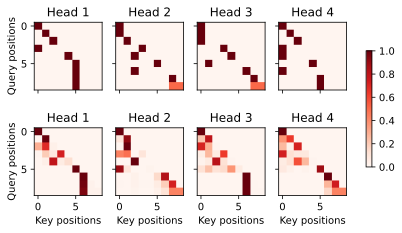

In [224]:
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))